# NLTK Sentiment Analysis 

In [1]:
# %pip install nltk

In [6]:
import os

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

os.chdir(base_dir)

os.getcwd()

'/opt/notebooks/psalms-text-comparison'

In [7]:
os.listdir("data")

['cleaned_psalm_verses.csv', 'grouped_psalm.csv']

In [8]:
import pandas as pd
psalm_verses = pd.read_csv("data/cleaned_psalm_verses.csv")
psalm_verses

,tradition,text,psalm_num,verse_num,verse
0,Orthodox,Bible,1,1,Blessed is the man Who walks not in the counse...
1,Orthodox,Bible,1,2,But his will is in the law of the Lord And in ...
2,Orthodox,Bible,1,3,He shall be like a tree Planted by streams of ...
3,Orthodox,Bible,1,4,Not so are the ungodly not so But they are lik...
4,Orthodox,Bible,1,5,Therefore the ungodly shall not rise in the ju...
...,...,...,...,...,...
4937,Orthodox,Psalter,150,1,Praise God in His holy ones; praise Him in the...
4938,Orthodox,Psalter,150,2,Praise Him for His mighty acts; praise Him acc...
4939,Orthodox,Psalter,150,3,Praise Him with the sound of the trumpet; prai...
4940,Orthodox,Psalter,150,4,Praise Him with the timbrel and dance; praise ...


In [9]:
psalms = pd.read_csv("data/grouped_psalm.csv")
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


# BERTopic Modeling

In [6]:
#%pip install bertopic

%pip install --force-reinstall \
    numpy==1.26.4 \
    scikit-learn==1.3.2 \
    umap-learn==0.5.5 \
    numba==0.58.1 \
    bertopic

In [2]:
#%pip install -q sentence-transformers
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [3]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")
topic_model = BERTopic(embedding_model=embedding_model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
docs = psalms["verse"].astype(str).tolist()

In [11]:
topics, probs = topic_model.fit_transform(docs)

In [12]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,85,-1_the_and_of_for,"[the, and, of, for, in, to, his, shall, you, l...","[O give thanks unto the Lord, for He is good; ..."
1,0,73,0_me_my_and_the,"[me, my, and, the, thy, of, in, for, lord, shall]","[O God my God, look to me; why hast Thou forsa..."
2,1,63,1_my_the_you_me,"[my, the, you, me, and, of, in, your, to, will]",[For the End concerning help in the morning a ...
3,2,43,2_the_of_and_his,"[the, of, and, his, lord, shall, all, in, is, he]","[I will sing of Thy mercies, O Lord, for ever;..."
4,3,27,3_the_and_of_he,"[the, and, of, he, their, them, they, his, in,...",[1Alleluia Give thanks to the Lord for He is g...
5,4,10,4_the_lord_of_be,"[the, lord, of, be, who, us, shall, blessed, h...","[If it had not been that the Lord was with us,..."


In [42]:
topic_model.visualize_topics()

In [51]:
psalms['cleaned_verse']

0      blessed man walk counsel ungodly stand way sin...
1      nation rage people meditate vain thing king ea...
2      psalm david fled face son absalom olord afflic...
3      end psalm ode david heard icalled god righteou...
4      end concerning inheritance psalm david give ea...
                             ...                        
296    lord doth build jerusalem ; shall gather toget...
297    praise lord , jerusalem ; praise thy god , zio...
298    praise ye lord heaven ; praise highest . prais...
299    sing unto lord new song , praise congregation ...
300     praise god holy one ; praise firmament power ...
Name: cleaned_verse, Length: 301, dtype: str

In [43]:
docs = psalms["cleaned_verse"].astype(str).tolist()

In [44]:
topics, probs = topic_model.fit_transform(docs)

In [45]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5,-1_praise_wrath_mercy_covenant,"[praise, wrath, mercy, covenant, shall, comman...",[understanding asaph ogod rejected u end anger...
1,0,165,0_righteousness_righteous_praise_salvation,"[righteousness, righteous, praise, salvation, ...","[give thee thanks , lord , whole heart : angel..."
2,1,112,1_psalm_righteousness_salvation_prayer,"[psalm, righteousness, salvation, prayer, righ...",[end concerning hidden thing son psalm david i...
3,2,19,2_righteousness_salvation_righteous_praise,"[righteousness, salvation, righteous, praise, ...",[alleluia praise name lord servant praise lord...


In [46]:
import pandas as pd

pd.Series(topics).unique()
#pd.Series(topics).count()

array([ 0,  1, -1,  2])

In [47]:
topic_words = topic_model.get_topics()

# topic_words

In [48]:
topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [50]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = topic_sets[t1] & topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'salvation', 'mercy', 'wrath', 'praise', 'righteous', 'righteousness'}
Count: 6

Topic 0 vs Topic 2
Shared words: {'salvation', 'righteousness', 'mercy', 'praise', 'righteous', 'sinner'}
Count: 6

Topic 1 vs Topic 2
Shared words: {'salvation', 'mercy', 'praise', 'righteous', 'righteousness'}
Count: 5



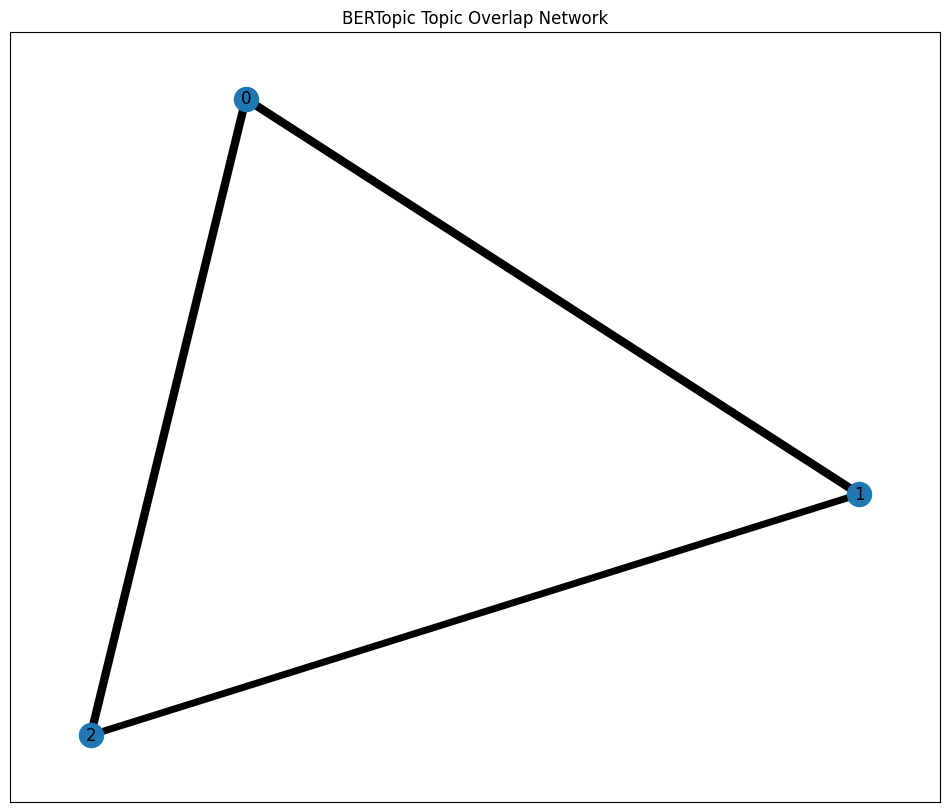

In [52]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

G = nx.Graph()

for topic in topic_sets:
    G.add_node(topic)

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = len(topic_sets[t1] & topic_sets[t2])

    if overlap > 0:
        G.add_edge(t1, t2, weight=overlap)

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths
)

plt.title("BERTopic Topic Overlap Network")
plt.show()

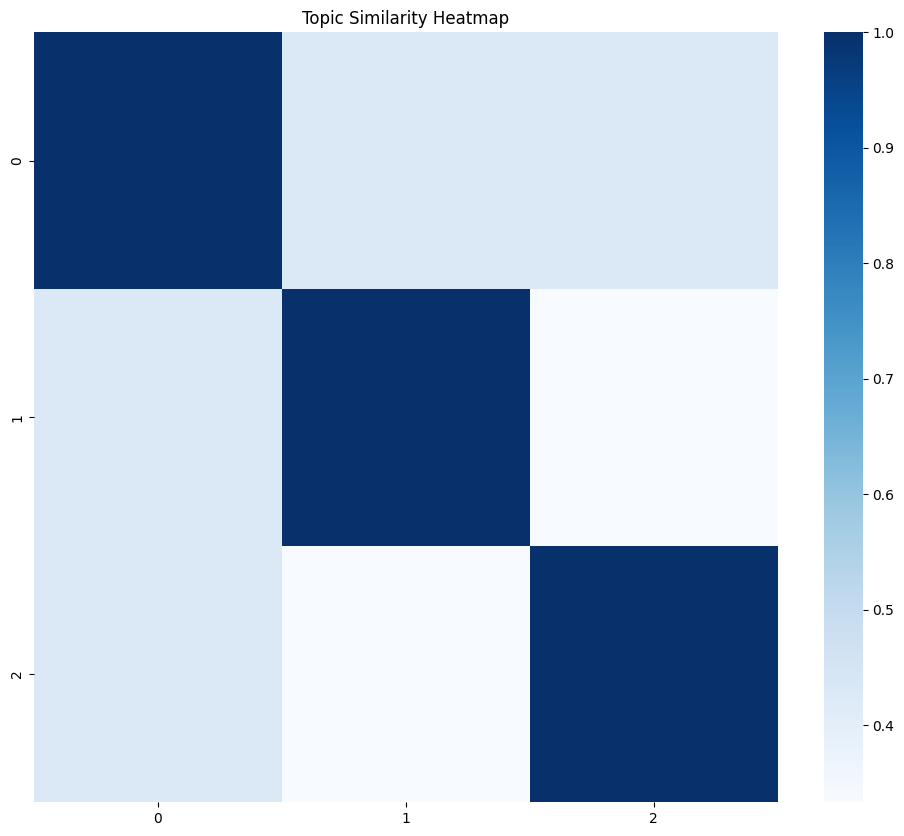

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Topic Similarity Heatmap")
plt.show()

In [100]:
from sklearn.cluster import KMeans

cluster_model = KMeans(
    n_clusters=5,
    random_state=42
)

topic_model = BERTopic(
    hdbscan_model=cluster_model
)

In [101]:
docs = psalms["cleaned_verse"].astype(str).tolist()

In [102]:
topics, probs = topic_model.fit_transform(docs)

topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,105,0_shall_lord_god_let,"[shall, lord, god, let, hand, man, day, soul, ...",[david envious evil jealous work lawlessness l...
1,1,62,1_thy_me_thou_lord,"[thy, me, thou, lord, shall, thee, unto, god, ...","[thee , lord , put hope ; let never put shame ..."
2,2,53,2_thy_thou_lord_shall,"[thy, thou, lord, shall, god, unto, ever, hast...","[give thanks unto thee , lord , whole heart ; ..."
3,3,50,3_lord_shall_unto_god,"[lord, shall, unto, god, ye, earth, hath, isra...","[sing unto lord new song ; sing unto lord , ea..."
4,4,31,4_lord_praise_forever_shall,"[lord, praise, forever, shall, endures, mercy,...",[concerning understanding asaph give heed peop...


In [103]:
topic_words = topic_model.get_topics()

# topic_words

In [104]:
topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [105]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = topic_sets[t1] & topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'lord', 'god', 'let', 'shall'}
Count: 4

Topic 0 vs Topic 2
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 0 vs Topic 3
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 0 vs Topic 4
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 1 vs Topic 2
Shared words: {'hast', 'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 8

Topic 1 vs Topic 3
Shared words: {'lord', 'god', 'unto', 'shall'}
Count: 4

Topic 1 vs Topic 4
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 2 vs Topic 3
Shared words: {'unto', 'god', 'shall', 'lord', 'hath'}
Count: 5

Topic 2 vs Topic 4
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 3 vs Topic 4
Shared words: {'lord', 'god', 'shall'}
Count: 3



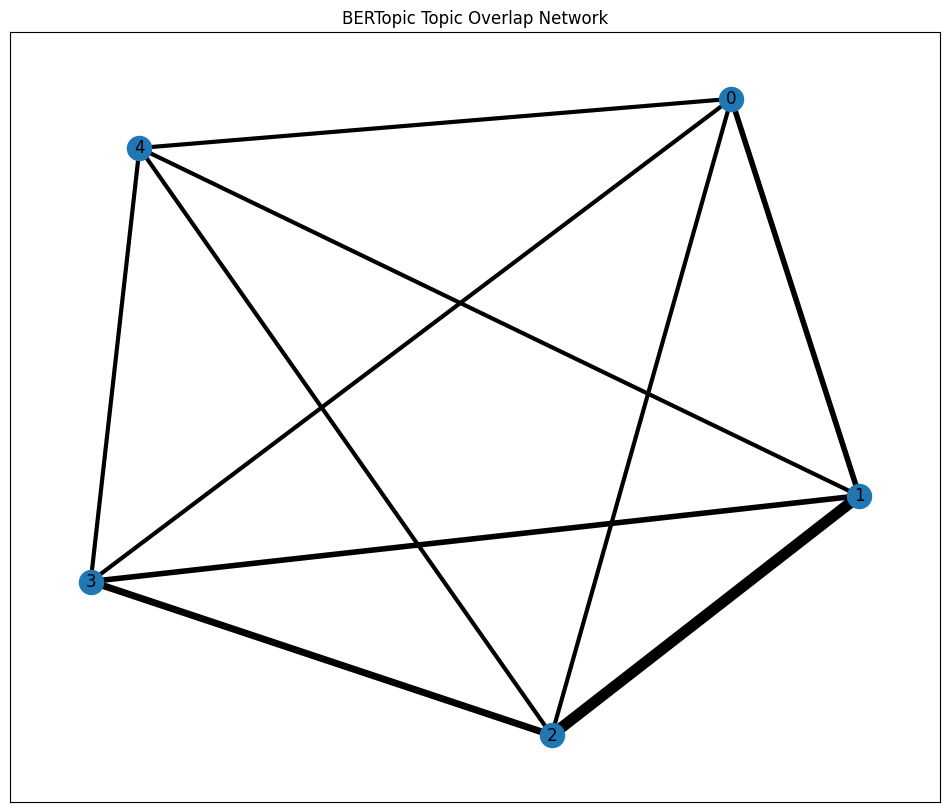

In [110]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

G = nx.Graph()

for topic in topic_sets:
    G.add_node(topic)

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = len(topic_sets[t1] & topic_sets[t2])

    if overlap > 0:
        G.add_edge(t1, t2, weight=overlap)

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths
)

plt.title("BERTopic Topic Overlap Network")
plt.show()

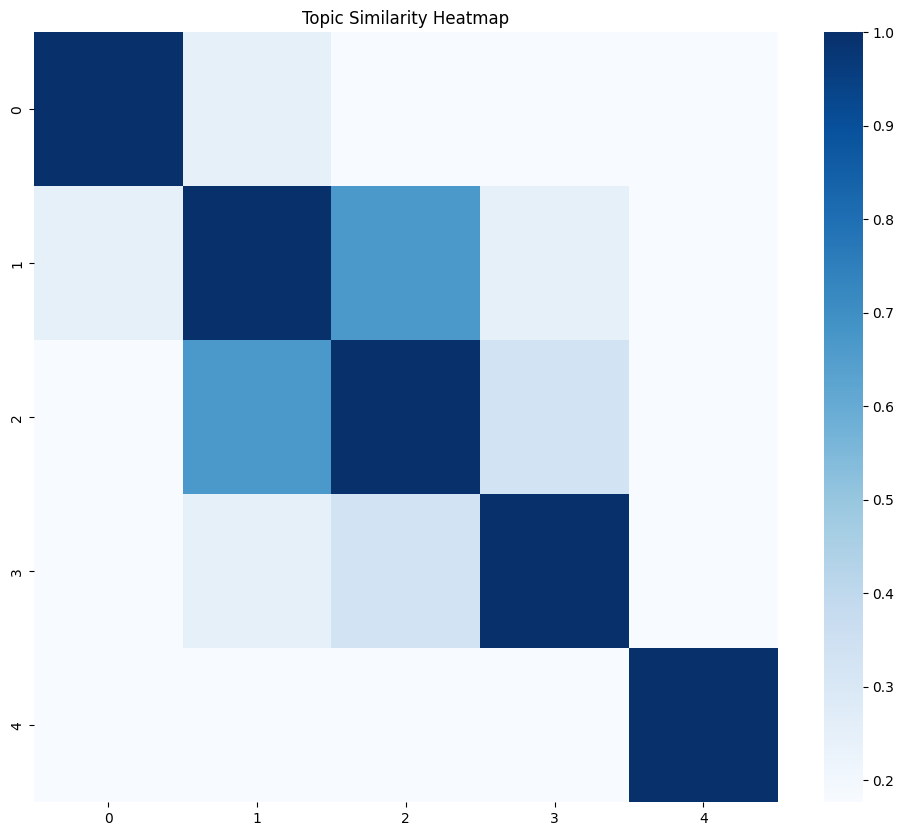

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Topic Similarity Heatmap")
plt.show()

## Topic modeling comparison

Looking at possible topics that are being models based on wheather it is a Psalms from the bible or the psalter

In [154]:
from sklearn.cluster import KMeans

cluster_model = KMeans(
    n_clusters=5,
    random_state=42
)

topic_model = BERTopic(
    hdbscan_model=cluster_model
)

In [155]:
bible = psalms[psalms['text'] == "Bible"]
bible

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,Topics_A
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,4
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,1
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,0
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,0
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,0
...,...,...,...,...,...,...,...
146,146,Orthodox,Bible,147,Alleluia of Aggeus and Zacharias Praise the Lo...,alleluia aggeus zacharias praise lord jerusale...,3
147,147,Orthodox,Bible,148,Alleluia of Aggeus and Zacharias Praise the Lo...,alleluia aggeus zacharias praise lord heaven p...,-1
148,148,Orthodox,Bible,149,1Alleluia Sing to the Lord a new song His prai...,onealleluia sing lord new song praise assembly...,-1
149,149,Orthodox,Bible,150,1Alleluia Praise God in His saints Praise Him ...,onealleluia praise god saint praise firmament ...,1


In [156]:
bible_topics, bible_probs = topic_model.fit_transform(bible['cleaned_verse'])

topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,64,0_shall_lord_god_let,"[shall, lord, god, let, hand, soul, like, day,...",[onefor end child lord david thing spoke lord ...
1,1,29,1_god_lord_shall_earth,"[god, lord, shall, earth, let, people, psalm, ...",[end ode psalm resurrection shout god earth si...
2,2,23,2_lord_god_end_shall,"[lord, god, end, shall, man, david, may, heart...",[end psalm david deliver lord evil man rescue ...
3,3,22,3_lord_forever_shall_commandment,"[lord, forever, shall, commandment, praise, me...",[concerning understanding asaph give heed peop...
4,4,13,4_lord_onean_ascent_ode,"[lord, onean, ascent, ode, like, shall, israel...",[onean ode ascent blessed fear lord walk way s...


In [157]:
topic_words = topic_model.get_topics()

# topic_words

In [158]:
bible_topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    bible_topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [159]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    bible_overlap = bible_topic_sets[t1] & bible_topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'lord', 'shall'}
Count: 2

Topic 0 vs Topic 2
Shared words: {'lord', 'shall'}
Count: 2

Topic 0 vs Topic 3
Shared words: {'lord', 'shall'}
Count: 2

Topic 0 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2

Topic 1 vs Topic 2
Shared words: {'lord', 'shall'}
Count: 2

Topic 1 vs Topic 3
Shared words: {'lord', 'shall'}
Count: 2

Topic 1 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2

Topic 2 vs Topic 3
Shared words: {'lord', 'shall'}
Count: 2

Topic 2 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2

Topic 3 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2



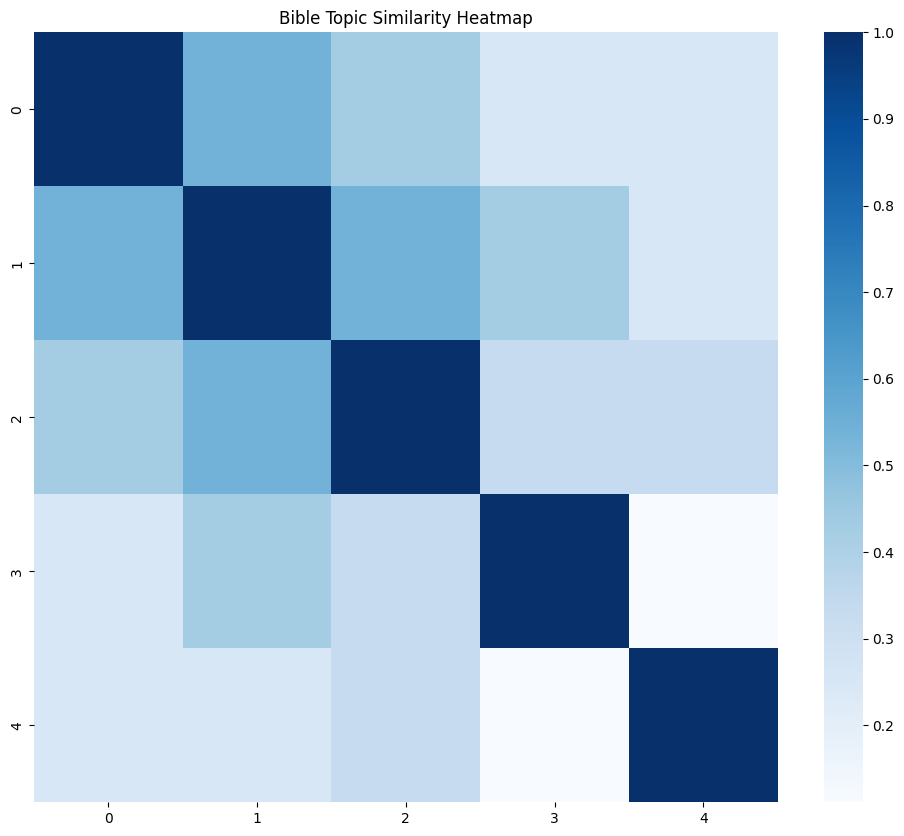

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(bible_topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Bible Topic Similarity Heatmap")
plt.show()

In [161]:
psalter = psalms[psalms['text'] == "Psalter"]
psalter

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,Topics_A
151,151,Orthodox,Psalter,1,Blessed is the man that hath not walked in the...,"blessed man hath walked counsel ungodly , stoo...",4
152,152,Orthodox,Psalter,2,"Why did the heathen rage, and the peoples imag...","heathen rage , people imagine vain thing ? kin...",5
153,153,Orthodox,Psalter,3,"Lord, why are they increased that trouble me? ...","lord , increased trouble me ? many rise me . m...",2
154,154,Orthodox,Psalter,4,"Thou hast heard me when I called upon Thee, O ...","thou hast heard called upon thee , god righteo...",2
155,155,Orthodox,Psalter,5,"Give ear to my words, O Lord; understand my cr...","give ear word , lord ; understand cry . give h...",2
...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,1
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...",3
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,1
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...",1


In [162]:
psalter_topics, psalter_probs = topic_model.fit_transform(psalter['cleaned_verse'])

topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,48,0_lord_thy_thou_god,"[lord, thy, thou, god, shall, unto, ever, hath...","[love thee , lord , strength . lord firm suppo..."
1,1,38,1_me_lord_thou_shall,"[me, lord, thou, shall, thy, unto, thee, god, ...","[god god , look me ; hast thou forsaken me ? f..."
2,2,25,2_shall_lord_god_unto,"[shall, lord, god, unto, thou, thy, earth, the...","[praise ye name lord ; ye servant , praise lor..."
3,3,22,3_thy_shall_lord_me,"[thy, shall, lord, me, thou, word, heart, comm...","[transgressor , may sin , saith within fear go..."
4,4,17,4_lord_praise_ye_earth,"[lord, praise, ye, earth, shall, glory, unto, ...","[clap hand , ye nation ; shout unto god voice ..."


In [163]:
topic_words = topic_model.get_topics()

# topic_words

In [164]:
psalter_topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    psalter_topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [165]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = psalter_topic_sets[t1] & psalter_topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'hast', 'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 8

Topic 0 vs Topic 2
Shared words: {'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 7

Topic 0 vs Topic 3
Shared words: {'thee', 'thy', 'thou', 'shall', 'lord'}
Count: 5

Topic 0 vs Topic 4
Shared words: {'lord', 'unto', 'shall'}
Count: 3

Topic 1 vs Topic 2
Shared words: {'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 7

Topic 1 vs Topic 3
Shared words: {'thee', 'thy', 'me', 'thou', 'shall', 'lord'}
Count: 6

Topic 1 vs Topic 4
Shared words: {'lord', 'unto', 'shall'}
Count: 3

Topic 2 vs Topic 3
Shared words: {'thee', 'thy', 'thou', 'shall', 'lord'}
Count: 5

Topic 2 vs Topic 4
Shared words: {'lord', 'earth', 'unto', 'shall'}
Count: 4

Topic 3 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2



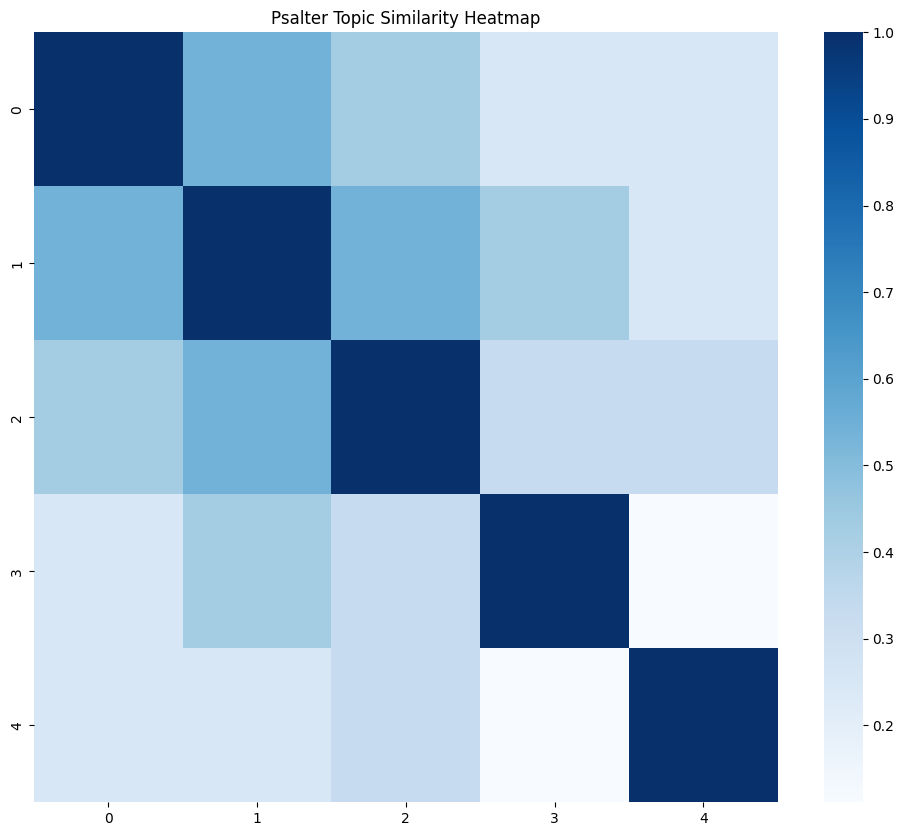

In [166]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(psalter_topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Psalter Topic Similarity Heatmap")
plt.show()

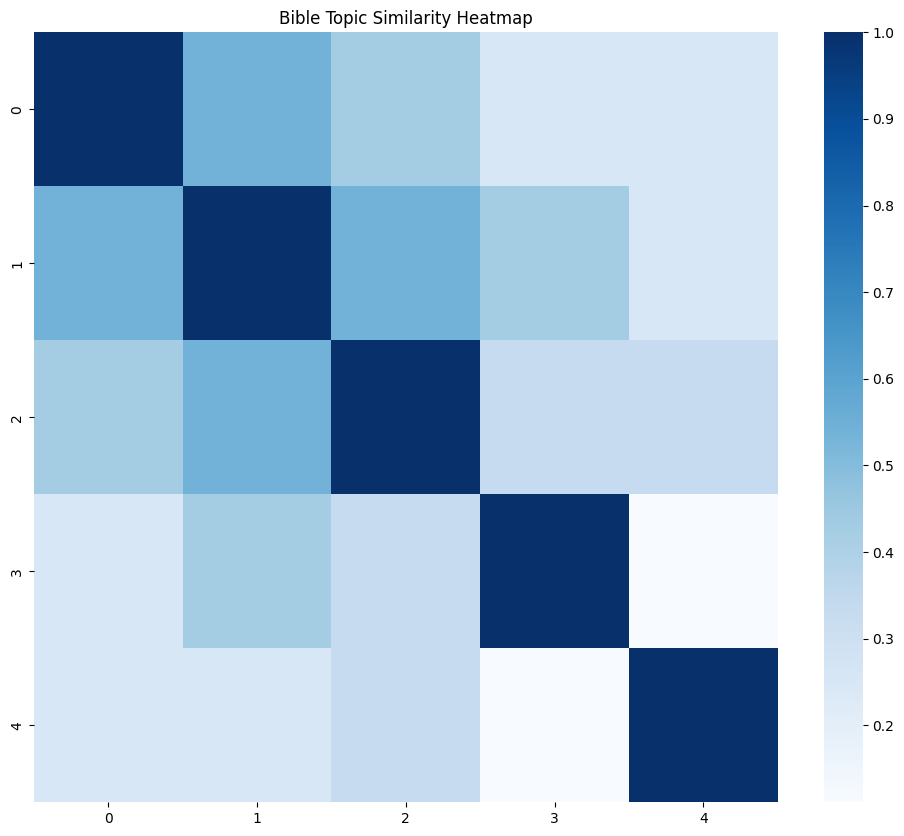

In [167]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(bible_topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Bible Topic Similarity Heatmap")
plt.show()

In [168]:
psalter_topic_sets

{0: {'ever',
  'god',
  'hast',
  'hath',
  'lord',
  'shall',
  'thee',
  'thou',
  'thy',
  'unto'},
 1: {'god',
  'hast',
  'let',
  'lord',
  'me',
  'shall',
  'thee',
  'thou',
  'thy',
  'unto'},
 2: {'earth',
  'god',
  'lord',
  'mountain',
  'shall',
  'thee',
  'thou',
  'thy',
  'unto',
  'upon'},
 3: {'commandment',
  'heart',
  'law',
  'lord',
  'me',
  'shall',
  'thee',
  'thou',
  'thy',
  'word'},
 4: {'earth',
  'glory',
  'heaven',
  'him',
  'lord',
  'people',
  'praise',
  'shall',
  'unto',
  'ye'}}

In [177]:
rows = []

for topic_id, words in psalter_topic_sets.items():
    for word in words:
        rows.append({
            "topic_id": topic_id,
            "Psalter - word": word
        })

df_topics = pd.DataFrame(rows)

df_topics

,topic_id,Psalter - word
0,0,hast
1,0,thee
2,0,ever
3,0,thy
4,0,unto
5,0,thou
6,0,god
7,0,shall
8,0,lord
9,0,hath


In [178]:
rows = []

for topic_id, words in bible_topic_sets.items():
    for word in words:
        rows.append({
            "topic_id": topic_id,
            "Bible - word": word
        })

bible_df_topics = pd.DataFrame(rows)

bible_df_topics

,topic_id,Bible - word
0,0,shall
1,0,heart
2,0,hand
3,0,god
4,0,let
5,0,lord
6,0,like
7,0,man
8,0,soul
9,0,day


In [185]:
overall_topics = pd.concat([bible_df_topics, df_topics], axis=1, join='inner').T.drop_duplicates().T

overall_topics

,topic_id,Bible - word,Psalter - word
0,0,shall,hast
1,0,heart,thee
2,0,hand,ever
3,0,god,thy
4,0,let,unto
5,0,lord,thou
6,0,like,god
7,0,man,shall
8,0,soul,lord
9,0,day,hath
